In [1]:
import networkx as nx, numpy as np, matplotlib.pyplot as plt
import os, importlib
from ripser import ripser

import test_WTM as wtm
import utilsA1 as utils
importlib.reload(utils)
importlib.reload(wtm)

PATH = os.getcwd()
output_file = "Test_GUDHI"
print(PATH)

C:\Users\sranasin\Desktop\NetworkModels\Project1\A1


### Basis

In [8]:
importlib.reload(wtm)
importlib.reload(utils)

params_temp_list = {'num_nodes': 10, 'num_neighbor_nodes': 1,
                    'total_random_edges': 2, 'distance_threshold': 1, 'weighted': True,
                    'ngeo_placement': 'ngeo_per_node', 'n_seeds': 1, 'node_active_threshold': 0.01,
                    'upper_weight_limit': 5, 'skew_power': 3, 'seed_cluster_distance': 10,
                    'seeding_method': 'cluster_seeding'}

G, seed_nodes = wtm.simulate_contagion_map(params=params_temp_list)
G, snapshots, activation_times, _ = wtm.simulate_contagion_realization(graph = G, init_seeds = seed_nodes, params = params_temp_list,
max_steps = 100, sim_id = 1, realization_id = 1)

utils.visualize_step_animation_new(G=G, snapshots=snapshots,
                         output_file= os.path.join(PATH, 'Outputs', f"{output_file}.html"))

In [170]:
print(activation_times)

[5. 6. 6. 5. 6. 6. 7. 7. 7. 6. 6. 5. 5. 4. 4. 3. 2. 2. 1. 1. 0. 2. 1. 2.
 2. 3. 3. 4. 4. 5.]


### Ripser Implementation

In [171]:

def ripser_track_simplexes(graph: nx.Graph, activation_times: np.ndarray):
    max_time = int(np.nanmax(activation_times))
    H0 = []
    H1 = []
    H2 = []

    for t in range(max_time + 1):
        active_nodes = [node for node, step in enumerate(activation_times) if step <= t]
        if len(active_nodes) <= 1:
            H0.append((t, len(active_nodes)))
            H1.append((t, 0))
            H2.append((t, 0))
            continue

        dist_matrix = utils.graph_to_distance_matrix(graph, active_nodes)

        ### Error here sometimes ????
        result = ripser(dist_matrix, distance_matrix=True, maxdim=2)
        h0_diagram = result['dgms'][0]
        h1_diagram = result['dgms'][1]
        h2_diagram = result['dgms'][2]

        H0.append((t, np.sum(np.isinf(h0_diagram[:, 1]))))
        H1.append((t, np.sum(np.isinf(h1_diagram[:, 1]))))
        H2.append((t, np.sum(np.isinf(h2_diagram[:, 1]))))

    return H0, H1, H2



In [172]:
H0, H1, H2 = ripser_track_simplexes(G, activation_times)
times_h0, h0_counts = zip(*H0)
times_h1, h1_counts = zip(*H1)
times_h2, h2_counts = zip(*H2)

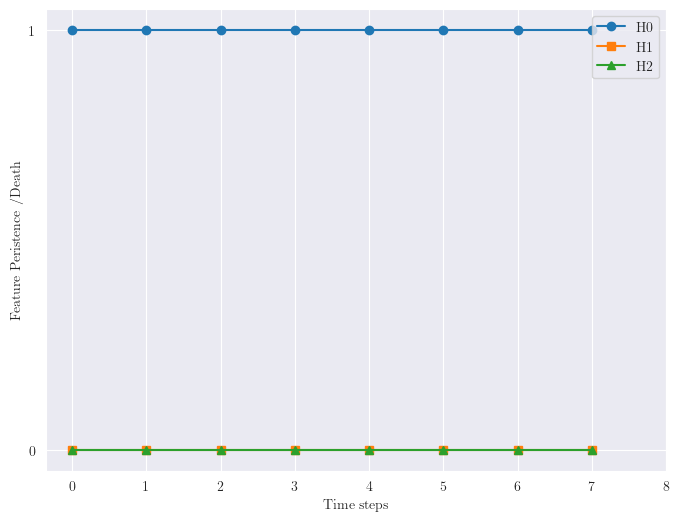

In [173]:
plt.figure(figsize=(8, 6))
plt.plot(times_h0, h0_counts, marker = 'o', label = 'H0')
plt.plot(times_h1, h1_counts, marker = 's', label = 'H1')
plt.plot(times_h2, h2_counts, marker = '^', label = 'H2')
plt.xlabel('Time steps')
plt.ylabel('Feature Peristence /Death')
plt.legend()
plt.xticks(range(0, max(times_h0) + 2))
plt.yticks(range(0, max(h0_counts) + 1))
plt.show()

### GUDHI Implementation

In [3]:
import gudhi
from collections import Counter, defaultdict
from itertools import combinations

importlib.reload(wtm)
importlib.reload(utils)

<module 'utilsA1' from 'C:\\Users\\sranasin\\Desktop\\NetworkModels\\Project1\\A1\\utilsA1.py'>

In [4]:
def persistent_over_time(graph:nx.Graph, activation_times:np.ndarray, max_dim:int=2):

    ## Include piece of code to handle np.nan's
    ## Set a mask to drop all np.nan's


    node_times = dict(zip(graph.nodes(), activation_times))
    max_time = int(np.max(activation_times))

    betti_over_time = {}

    # For Each time step add the subgraph by nodes and vertex to the subtree as a filtration
    # make sure to set non_decreasing()
    for t in range(max_time + 1):
        active_nodes = [v for v in graph.nodes if node_times[v] <= t]
        subG = graph.subgraph(active_nodes).copy()

        tree = gudhi.SimplexTree()

        for v in subG.nodes:
            tree.insert([v], filtration=t)

        cliques = list(nx.find_cliques(subG))
        for clique in cliques:
            for k in range(1, max_dim + 1):
                for simplex in combinations(clique, k + 1):
                    tree.insert(simplex, filtration=t)


        tree.make_filtration_non_decreasing()
        tree.compute_persistence()
        betti_nums = tree.betti_numbers()

        betti_dict = dict()
        for dim in range(max_dim + 1):
            if dim < len(betti_nums):
                betti_dict[dim] = betti_nums[dim]
            else:
                betti_dict[dim] = 0
        betti_over_time[t] = betti_dict

    return betti_over_time


def betti_persistence_counts(betti_over_time:dict):
    times = sorted(betti_over_time.keys())
    dims = sorted(next(iter(betti_over_time.values())).keys())

    for dim in dims:
        values = [betti_over_time[t][dim] for t in times]
        plt.plot(times, values, label=f"H{dim}")

    plt.xlabel("Time Stesp")
    plt.ylabel("Feature Counts")
    plt.title("Betti Couts")
    plt.legend()
    plt.grid(True)
    plt.show()

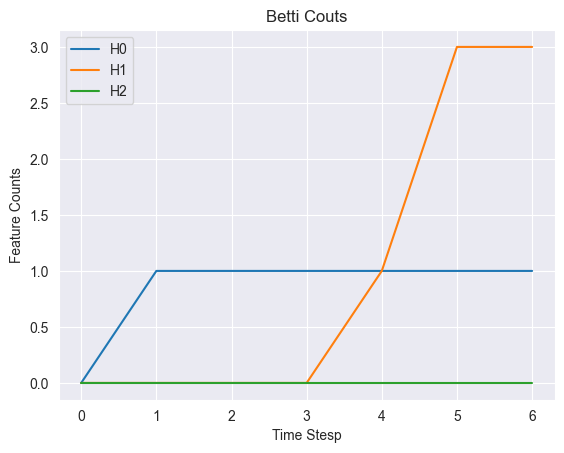

In [5]:
# Homology Group counts -- Betti Counts
persistence_dict = persistent_over_time(G, activation_times, max_dim=2)
betti_persistence_counts(persistence_dict)

In [6]:
def persistence_birth_death_by_dim(graph:nx.Graph, activation_times:np.ndarray, max_dim:int=2):
    assert len(activation_times) == graph.number_of_nodes()

    tree = gudhi.SimplexTree()
    node_times = dict(zip(graph.nodes, activation_times))

    for v in graph.nodes:
        tree.insert([v], filtration=node_times[v])

    cliques = list(nx.find_cliques(graph))

    for clique in cliques:
        for k in range(1, max_dim + 1):
            for simplex in combinations(clique, k + 1):
                filt = max(node_times[v] for v in simplex)
                tree.insert(simplex, filtration=filt)

    tree.make_filtration_non_decreasing()
    tree.compute_persistence()

    diag = tree.persistence()

    dim_dict = defaultdict(list)
    for dim, (birth, death) in diag:
        dim_dict[dim].append((birth, death))

    return dim_dict

def plot_persistence_barcodes(dim_dict, max_dim=2):
    plt.figure(figsize=(10, 6))
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    for dim in range(max_dim + 1):
        intervals = dim_dict.get(dim, [])
        for i, (birth, death) in enumerate(intervals):
            death_val = death if death != float('inf') else max(birth + 1, 50)
            plt.hlines(y=dim + i * 0.1, xmin=birth, xmax=death_val, color=colors[dim % len(colors)])
        plt.axhline(dim, linestyle='--', color='gray', alpha=0.5)

    plt.xlabel("Filtration (activation time)")
    plt.ylabel("Homology class index")
    plt.title("Persistence Barcodes (H0, H1, H2)")
    plt.yticks([])
    plt.grid(True)
    plt.show()


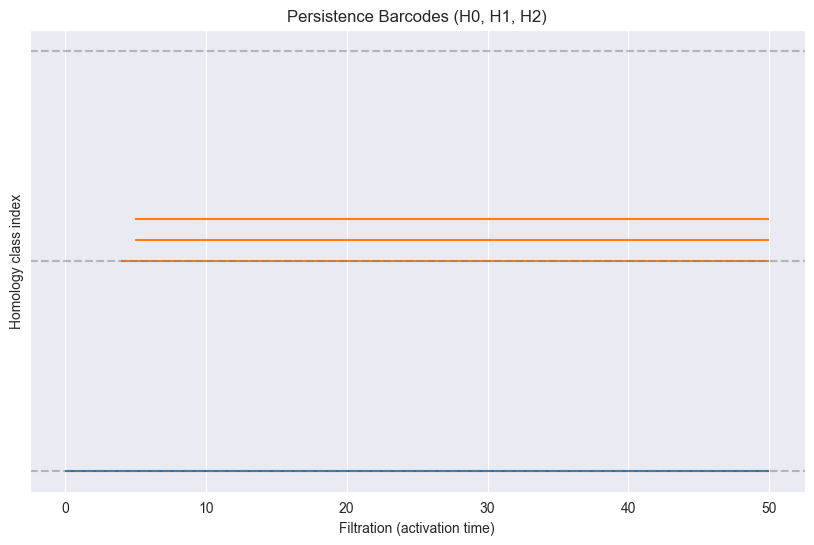

In [7]:
diag_by_dim = persistence_birth_death_by_dim(G, activation_times, max_dim=2)
plot_persistence_barcodes(diag_by_dim)

[(4.0, inf), (5.0, inf), (5.0, inf)]